In [1]:
import json
from pathlib import Path

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer
from skmultilearn.model_selection import iterative_train_test_split

In [2]:
DIR_PATH = "images/"

In [3]:
root = Path(DIR_PATH)

In [4]:
file_count = 0

In [5]:
for item in root.rglob("*"):
    if item.is_file():
        file_count += 1

In [6]:
file_count  # type: ignore

17361

we have almost seventeen thousand image files in our data set

In [7]:
with open(r"data/minifigs.json", "r") as file:
    df = pd.DataFrame(json.load(file))

In [8]:
df.head(3)

,id,name,link,year,img_url,minifig_number,category,subcategory,year_released,set_id,current_value_new,current_value_used,character_name,img_local_path,themes
0,1,"LEGOLAND - Black Torso, Black Legs, Black Cowb...",/minifigs/old040/legoland-black-torso-black-le...,1975,https://img.bricklink.com/ItemImage/MN/0/old04...,OLD040,LEGOLAND,General,1975,1 set,~€5.28,~€1.85,NaN,images/OLD040.jpg,[LEGOLAND]
1,2,"LEGOLAND - Black Torso, Black Legs, Black Hat",/minifigs/old011/legoland-black-torso-black-le...,1975,https://img.bricklink.com/ItemImage/MN/0/old01...,OLD011,LEGOLAND,General,1975,7 sets,Not known,~€1.53,NaN,images/OLD011.jpg,"[Basic, LEGOLAND, Universal Building Set]"
2,3,"LEGOLAND - Black Torso, Black Legs, White Hat",/minifigs/old009/legoland-black-torso-black-le...,1975,https://img.bricklink.com/ItemImage/MN/0/old00...,OLD009,LEGOLAND,General,1975,2 sets,~€3.37,~€1.42,NaN,images/OLD009.jpg,[LEGOLAND]


In [9]:
len(df)

17362

There is one more image metadata than there are actually image files. Have to inspect it further

In [10]:
df.isna().sum()

id                       0
name                     0
link                     0
year                     0
img_url                  0
minifig_number           0
category                 0
subcategory              0
year_released            0
set_id                   0
current_value_new        0
current_value_used       0
character_name        7883
img_local_path           1
themes                   0
dtype: int64

there is an image without a local path. we can drop this one

In [11]:
df.dropna(subset=["img_local_path"], inplace=True)

In [12]:
len(df)

17361

In [13]:
df["themes"].value_counts()

themes
[City]                                    1977
[Star Wars]                               1439
[Ninjago]                                  920
[Friends]                                  872
[Collectable Minifigures]                  765
                                          ... 
[BrickLink, City, Ideas]                     1
[City, Friends]                              1
[Icons, Ideas, Promotional]                  1
[City, Icons, Miscellaneous, Seasonal]       1
[BrickLink, Ideas]                           1
Name: count, Length: 313, dtype: int64

In [14]:
theme_counts = df["themes"].apply(len)
theme_counts.head()

0    1
1    3
2    1
3    1
4    1
Name: themes, dtype: int64

In [15]:
multi_label_counts = (theme_counts > 1).sum()

In [16]:
multi_label_counts

np.int64(637)

In [17]:
print(f"Number of images with multiple labels: {multi_label_counts}")

Number of images with multiple labels: 637


In [18]:
total_images = len(df)

In [19]:
single_label_counts = total_images - multi_label_counts
single_label_counts

np.int64(16724)

In [20]:
print(f"Number of images with only one label: {single_label_counts}")

Number of images with only one label: 16724


In [21]:
print(
    f"Percentage of multi-label images: {(multi_label_counts / total_images ) * 100:.2f}%"
)

Percentage of multi-label images: 3.67%


so the data is heavily skewed towards images with single labels.

In [22]:
all_labels = df["themes"].explode()
all_labels

0                      LEGOLAND
1                         Basic
1                      LEGOLAND
1        Universal Building Set
2                      LEGOLAND
                  ...          
17357                   Ninjago
17358                   Ninjago
17359                   Ninjago
17360                  Dreamzzz
17361                 Minecraft
Name: themes, Length: 18123, dtype: str

In [23]:
theme_counts = all_labels.value_counts()
theme_counts

themes
City             2001
Star Wars        1477
Ninjago           929
Friends           877
Duplo             836
                 ... 
Bulk Bricks         1
Discovery           1
Quatro              1
LEGO Universe       1
Xtra                1
Name: count, Length: 144, dtype: int64

In [24]:
theme_counts.index.nunique()

144

so there are 144 unique themes in the dataset. but it seems a bit too high. I want to find the right cut off to trim the data a bit, and avoid those rare themes

In [25]:
thresholds = [1, 5, 10, 20, 30, 40, 50, 75, 100]
num_images_kept = []
num_themes_kept = []

In [26]:
for t in thresholds:
    kept_themes = set(theme_counts[theme_counts >= t].index)

    kept_mask = df["themes"].apply(lambda x: bool(set(x) & kept_themes))

    num_images_kept.append(kept_mask.sum())
    num_themes_kept.append(len(kept_themes))

In [27]:
num_images_kept

[np.int64(17361),
 np.int64(17338),
 np.int64(17277),
 np.int64(17021),
 np.int64(16566),
 np.int64(16147),
 np.int64(15860),
 np.int64(15440),
 np.int64(14810)]

In [28]:
num_themes_kept

[144, 130, 119, 96, 75, 62, 55, 47, 39]

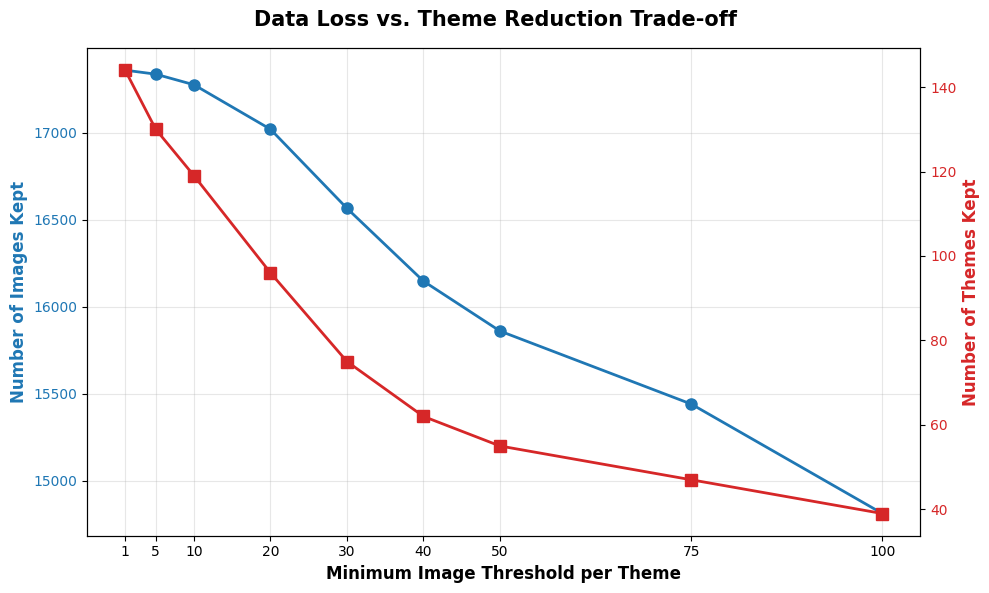

In [29]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# images kept
color = "tab:blue"
ax1.set_xlabel("Minimum Image Threshold per Theme", fontsize=12, fontweight="bold")
ax1.set_ylabel("Number of Images Kept", color=color, fontsize=12, fontweight="bold")
ax1.plot(
    thresholds,
    num_images_kept,
    color=color,
    marker="o",
    markersize=8,
    linewidth=2,
    label="Images Kept",
)
ax1.tick_params(axis="y", labelcolor=color)
ax1.set_xticks(thresholds)
ax1.grid(True, alpha=0.3)

# themes kept
ax2 = ax1.twinx()
color = "tab:red"
ax2.set_ylabel("Number of Themes Kept", color=color, fontsize=12, fontweight="bold")
ax2.plot(
    thresholds,
    num_themes_kept,
    color=color,
    marker="s",
    markersize=8,
    linewidth=2,
    label="Themes Kept",
)

ax2.tick_params(axis="y", labelcolor=color)

fig.suptitle(
    "Data Loss vs. Theme Reduction Trade-off", fontsize=15, fontweight="bold"
)
fig.tight_layout()

In [30]:
print("\n--- Decision Matrix ---\n")
for t, themes, images in zip(thresholds, num_themes_kept, num_images_kept):
    loss = ((total_images - images) / total_images) * 100
    print(
        f"Cutoff {t:2d} -> Keep {themes:3d} themes | Keep {images:3,} images (Loss: {loss:.1f}%)"
    )


--- Decision Matrix ---

Cutoff  1 -> Keep 144 themes | Keep 17,361 images (Loss: 0.0%)
Cutoff  5 -> Keep 130 themes | Keep 17,338 images (Loss: 0.1%)
Cutoff 10 -> Keep 119 themes | Keep 17,277 images (Loss: 0.5%)
Cutoff 20 -> Keep  96 themes | Keep 17,021 images (Loss: 2.0%)
Cutoff 30 -> Keep  75 themes | Keep 16,566 images (Loss: 4.6%)
Cutoff 40 -> Keep  62 themes | Keep 16,147 images (Loss: 7.0%)
Cutoff 50 -> Keep  55 themes | Keep 15,860 images (Loss: 8.6%)
Cutoff 75 -> Keep  47 themes | Keep 15,440 images (Loss: 11.1%)
Cutoff 100 -> Keep  39 themes | Keep 14,810 images (Loss: 14.7%)


So based on the plot and the decision matrix, I choose the cutoff of 50. meaning that a theme must have at lest 50 images to be kept; otherwise it is discarded

In [31]:
MIN_NUM_IMAGES = 50

In [32]:
kept_themes_counts = theme_counts[theme_counts >= MIN_NUM_IMAGES]

In [33]:
kept_themes_counts

themes
City                            2001
Star Wars                       1477
Ninjago                          929
Friends                          877
Duplo                            836
Collectable Minifigures          782
Marvel Super Heroes              703
Town                             700
Harry Potter                     637
Castle                           459
Education                        454
Disney                           387
DC Comics Super Heroes           308
Icons                            294
Ideas                            279
BrickLink                        270
Promotional                      258
Dacta                            253
Minecraft                        251
Sports                           234
Super Mario                      229
Seasonal                         227
Gear                             200
Monkie Kid                       182
Space                            172
Creator                          166
Legends of Chima               

In [34]:
kept_themes = kept_themes_counts.index
kept_themes

Index(['City', 'Star Wars', 'Ninjago', 'Friends', 'Duplo',
       'Collectable Minifigures', 'Marvel Super Heroes', 'Town',
       'Harry Potter', 'Castle', 'Education', 'Disney',
       'DC Comics Super Heroes', 'Icons', 'Ideas', 'BrickLink', 'Promotional',
       'Dacta', 'Minecraft', 'Sports', 'Super Mario', 'Seasonal', 'Gear',
       'Monkie Kid', 'Space', 'Creator', 'Legends of Chima', 'Nexo Knights',
       'Pirates', 'Speed Champions', 'Creator Expert', 'Juniors',
       'Miscellaneous', 'Jurassic World', 'Trains', 'Games', 'Belville',
       'Dreamzzz', 'Advanced models', 'The LEGO Batman Movie',
       'The LEGO Ninjago Movie', 'Fabuland', 'The LEGO Movie 2', 'Explore',
       'Racers', 'The LEGO Movie', 'Hidden Side', 'Dimensions', 'The Hobbit',
       'Elves', 'Basic', 'Indiana Jones', 'Cars',
       'Teenage Mutant Ninja Turtles', 'Adventurers'],
      dtype='str', name='themes')

In [35]:
len(kept_themes)

55

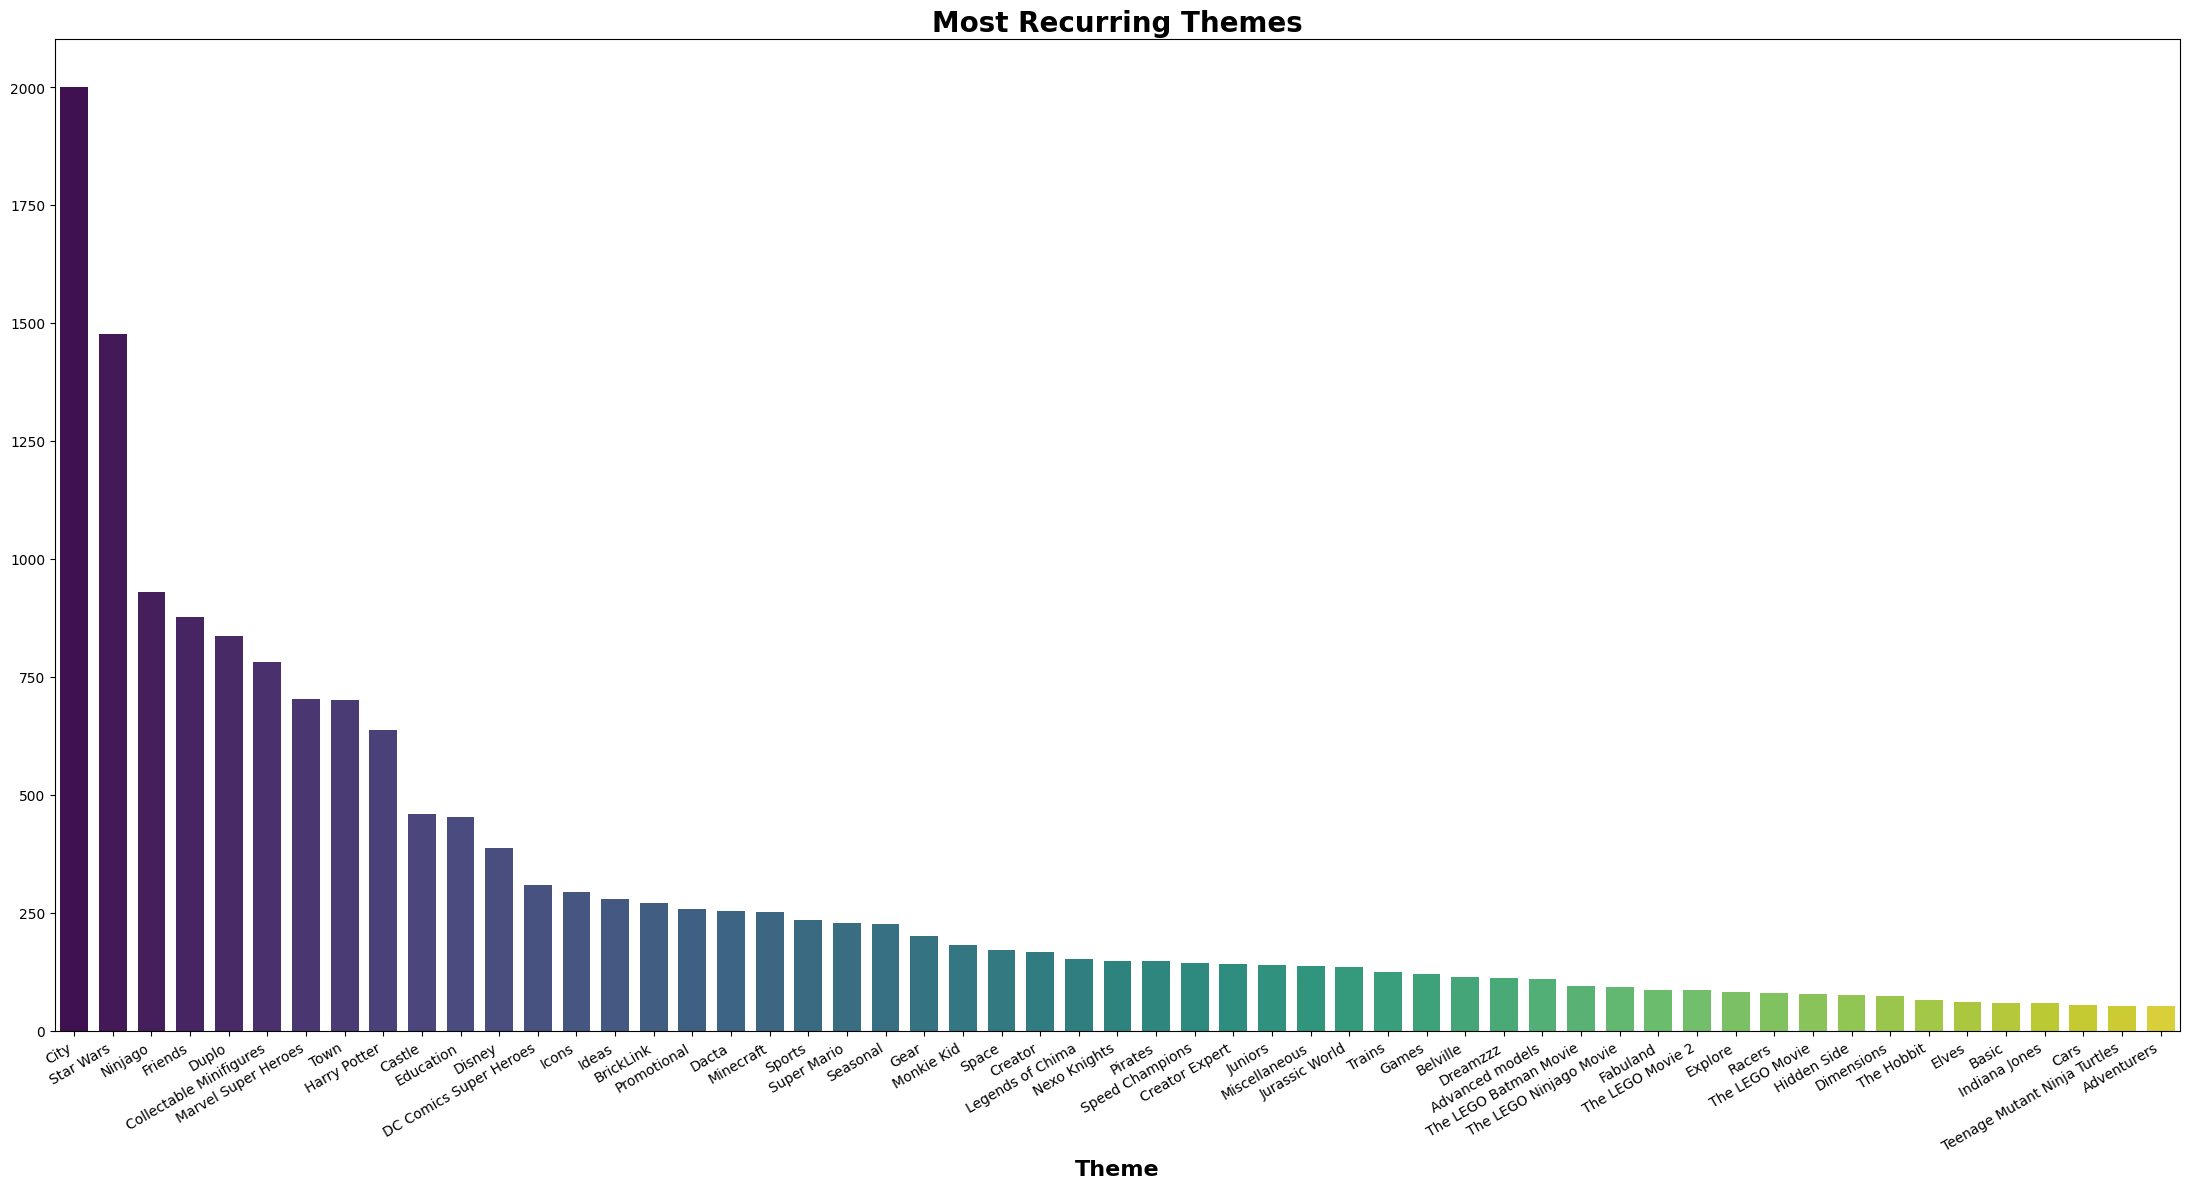

In [36]:
fig, ax = plt.subplots(figsize=(22, 12))

sns.barplot(
    ax=ax,
    x=kept_themes,
    y=kept_themes_counts.values,
    palette="viridis",
    hue=kept_themes,
    gap=0.1
)

ax.set_title("Most Recurring Themes", fontsize=20, fontweight="bold")
ax.set_xlabel("Theme", fontsize=16, fontweight="bold")

for label in ax.get_xticklabels():
    label.set_rotation(30)
    label.set_ha("right")  # type: ignore

fig.tight_layout()

In [37]:
df["themes"] = df["themes"].apply(lambda themes: [t for t in themes if t in kept_themes])

In [38]:
df = df[df["themes"].map(len) > 0].reset_index(drop=True)

In [39]:
len(df)

15860

In [40]:
df.sample(3, random_state=36)

,id,name,link,year,img_url,minifig_number,category,subcategory,year_released,set_id,current_value_new,current_value_used,character_name,img_local_path,themes
9184,10339,Aurora - Open Mouth with Roses on Dress,/minifigs/dp064/aurora-open-mouth-with-roses-o...,2019,https://img.bricklink.com/ItemImage/MN/0/dp064...,DP064,Disney,Disney Princess / Sleeping Beauty,2019,1 set,~€7.46,~€3.19,Aurora,images/DP064.jpg,[Disney]
679,727,"Breastplate - Armor over Red, Dark Gray Helmet...",/minifigs/cas171/breastplate-armor-over-red-da...,1990,https://img.bricklink.com/ItemImage/MN/0/cas17...,CAS171,Castle,Lion Knights,1990,1 set,~€29.50,~€11.68,NaN,images/CAS171.jpg,[Castle]
3698,4396,"Kingdoms - Dragon Knight Quarters, Helmet Clos...",/minifigs/cas464/kingdoms-dragon-knight-quarte...,2010,https://img.bricklink.com/ItemImage/MN/0/cas46...,CAS464,Castle,Kingdoms,2010,1 set,~€21.74,~€11.92,NaN,images/CAS464.jpg,[Castle]


In [41]:
(df["themes"].apply(len) > 1).sum() # number of multi-label images

np.int64(513)

In [42]:
mlb = MultiLabelBinarizer()

In [43]:
X = df[["img_local_path"]].values

In [44]:
X

array([['images/OLD011.jpg'],
       ['images/OLD007.jpg'],
       ['images/OLD013.jpg'],
       ...,
       ['images/NJO1003.jpg'],
       ['images/DRM100.jpg'],
       ['images/MIN245.jpg']], shape=(15860, 1), dtype=object)

In [45]:
y = mlb.fit_transform(df["themes"])

In [46]:
type(y)

numpy.ndarray

In [47]:
y

array([[0, 0, 1, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 1],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(15860, 55))

In [48]:
print(f"Total unique themes encoded: {len(mlb.classes_)}")

Total unique themes encoded: 55


In [49]:
np.random.seed(10)

In [50]:
X_train, y_train, X_temp, y_temp = iterative_train_test_split(X, y, test_size=0.2)

In [51]:
X_valid, y_valid, X_test, y_test = iterative_train_test_split(
    X_temp, y_temp, test_size=0.5
)

In [52]:
print(f"Train set size: {len(X_train)} images")
print(f"Validation set size: {len(X_valid)} images")
print(f"Test set size: {len(X_test)} images")

Train set size: 12678 images
Validation set size: 1593 images
Test set size: 1589 images


In [53]:
y_test

array([[0, 0, 1, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1589, 55))

In [54]:
X_valid

array([['images/OLD013.jpg'],
       ['images/OLD019.jpg'],
       ['images/OLD006.jpg'],
       ...,
       ['images/DRM051.jpg'],
       ['images/BDP108.jpg'],
       ['images/BDP126.jpg']], shape=(1593, 1), dtype=object)

In [55]:
theme_columns = mlb.classes_

In [56]:
theme_columns[:10]

array(['Advanced models', 'Adventurers', 'Basic', 'Belville', 'BrickLink',
       'Cars', 'Castle', 'City', 'Collectable Minifigures', 'Creator'],
      dtype=object)

In [57]:
def save_split_to_csv(X_split, y_split, columns, filename):
    """
    Combines paths and labels into a single DataFrame and saves it.
    """

    df_paths = pd.DataFrame(X_split, columns=["img_local_path"])

    df_labels = pd.DataFrame(y_split, columns=columns)

    final_df = pd.concat([df_paths, df_labels], axis=1)

    final_df.to_csv(filename, index=False)
    print(f"Successfully saved {filename} ({len(final_df)} images)")

In [58]:
save_split_to_csv(X_train, y_train, theme_columns, "data/train_data.csv")
save_split_to_csv(X_valid, y_valid, theme_columns, "data/valid_data.csv")
save_split_to_csv(X_test, y_test, theme_columns, "data/test_data.csv")

Successfully saved data/train_data.csv (12678 images)
Successfully saved data/valid_data.csv (1593 images)
Successfully saved data/test_data.csv (1589 images)
